In [1]:
import numpy as np
import pandas as pd
import time

In [2]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df = df[['Age','EstimatedSalary','Purchased']]

In [5]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [7]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [ ]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
X_scaled.shape

(400, 2)

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
#X_train.shape

In [11]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [12]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
X_train.shape[0]

320

In [20]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(X_scaled,y,epochs=500,validation_split=0.2)
print(time.time() - start)

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9251 - loss: 0.2003 - val_accuracy: 0.9375 - val_loss: 0.2464
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9108 - loss: 0.2036 - val_accuracy: 0.9375 - val_loss: 0.2451
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8890 - loss: 0.2235 - val_accuracy: 0.9375 - val_loss: 0.2449
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9121 - loss: 0.2093 - val_accuracy: 0.9375 - val_loss: 0.2448
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8963 - loss: 0.2276 - val_accuracy: 0.9375 - val_loss: 0.2459
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9108 - loss: 0.2191 - val_accuracy: 0.9375 - val_loss: 0.2462
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9101 - loss: 0.2141 - val_accuracy: 0.9375 - val_loss: 0.2458
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8998 - loss: 0.2090 - val_accuracy: 0.9375 

KeyboardInterrupt: 

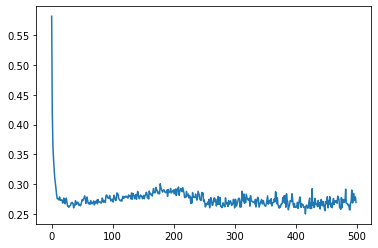

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])

In [ ]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [ ]:
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
#start = time.time()
history = model.fit(X_scaled,y,epochs=10,batch_size=250,validation_split=0.2)
#print(time.time() - start)

Epoch 1/10
2/2 [==============================] - 2s 305ms/step - loss: 0.6440 - accuracy: 0.7125 - val_loss: 0.7794 - val_accuracy: 0.3625
Epoch 2/10
2/2 [==============================] - 0s 45ms/step - loss: 0.6296 - accuracy: 0.7125 - val_loss: 0.7736 - val_accuracy: 0.3625
Epoch 3/10
2/2 [==============================] - 0s 71ms/step - loss: 0.6204 - accuracy: 0.7125 - val_loss: 0.7695 - val_accuracy: 0.3625
Epoch 4/10
2/2 [==============================] - 0s 50ms/step - loss: 0.6125 - accuracy: 0.7125 - val_loss: 0.7659 - val_accuracy: 0.3625
Epoch 5/10
2/2 [==============================] - 0s 47ms/step - loss: 0.6055 - accuracy: 0.7125 - val_loss: 0.7608 - val_accuracy: 0.3625
Epoch 6/10
2/2 [==============================] - 0s 50ms/step - loss: 0.5990 - accuracy: 0.7125 - val_loss: 0.7593 - val_accuracy: 0.3625
Epoch 7/10
2/2 [==============================] - 0s 39ms/step - loss: 0.5928 - accuracy: 0.7125 - val_loss: 0.7558 - val_accuracy: 0.3625
Epoch 8/10
2/2 [==========

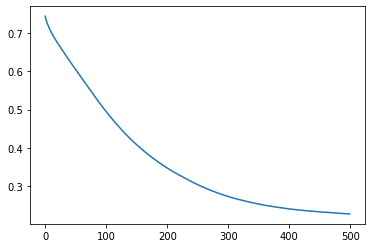

In [ ]:
plt.plot(history.history['loss'])